In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pathresults = "../scripts/results/"
data_file_delimiter = ","
import plotnine

from plotnine import *

# get param set
paramsets =  pd.read_csv('../scripts/output_random_rows.csv')
paramsets = paramsets.drop(paramsets.columns.tolist()[-1],axis=1)

paramsets.drop('theta',inplace=True, axis=1)

df = pd.read_pickle("./pset3_allcell_A.pkl")  # cid, pSet, rr, 1 or 9

df.columns=['cell'+str(cc) for cc in range(9)]+list(df.columns[9:])
dfnew = df.loc[df['vals']!='1dcoord'].reset_index(drop=True).copy()
alltime = df['time'].unique()

In [3]:
import sys;
sys.path.append("../../../../CPlantBox/");
sys.path.append("../../../../CPlantBox/src")
import functional.van_genuchten as vg

vg_soil = vg.Parameters([0.08, 0.43, 0.04, 1.6, 50]) 

In [5]:
dfcoord = df.loc[df['vals']=='1dcoord'].reset_index(drop=True).copy()

In [6]:
# from root center
for cid in range(9):
    dfcoord['rIn'+str(cid)] = -1
    dfcoord['rOut'+str(cid)] = -1

dfcoord.loc[((dfcoord['st']==0)),'rIn0']=0.05
dfcoord.loc[((dfcoord['st']==3)),'rIn0']=0.05
dfcoord.loc[((dfcoord['st']==1)),'rIn0']=0.02
dfcoord.loc[((dfcoord['st']==2)),'rIn0']=0.02

dfcoord['rOut0'] = (dfcoord['cell0'] - dfcoord['rIn0'])*2+dfcoord['rIn0']


for cellid in range(1,9):
    dfcoord['rIn'+str(cellid)] =np.array(list(dfcoord['rOut'+str(cellid-1)]))
    dfcoord['rOut'+str(cellid)] = (dfcoord['cell'+str(cellid)]
                                               - dfcoord['rIn'+str(cellid)])*2+dfcoord['rIn'+str(cellid)]

In [7]:
# from root surface
for cid in range(9):
    dfcoord['rInS'+str(cid)] = dfcoord['rIn'+str(cid)]-dfcoord['rIn0']
    dfcoord['rOutS'+str(cid)] = dfcoord['rOut'+str(cid)]-dfcoord['rIn0']
    dfcoord['cellS'+str(cid)] = dfcoord['cell'+str(cid)]-dfcoord['rIn0']



In [11]:
dfcoord.to_pickle('./pset3_allcell_Acoord.pkl')

##########

In [5]:
dfcoord =   pd.read_pickle(r'./pset3_allcell_Acoord.pkl')

In [76]:
# redefine vale in rhizosphere

In [6]:
dfcs = df.loc[df['vals']=='cs'].reset_index(drop=True).copy()
dfcoa = df.loc[df['vals']=='coa'].reset_index(drop=True).copy()
dfcod = df.loc[df['vals']=='cod'].reset_index(drop=True).copy()
dfcca = df.loc[df['vals']=='cca'].reset_index(drop=True).copy()
dfccd = df.loc[df['vals']=='ccd'].reset_index(drop=True).copy()

In [8]:
#get everything per volume of bulk soil -- scv
colvalsname = ['cell'+str(i) for i in range(9)]

# just create data frames before replacing the values
dfccat = dfcca.copy()
dfcc =  dfcca.copy()
dfco =  dfcoa.copy()

dfcc[colvalsname] = dfcca[colvalsname] +  dfccd[colvalsname] 
dfco[colvalsname] = dfcoa[colvalsname] +  dfcod[colvalsname] 
dfccat[colvalsname] = ( dfcca[colvalsname] + dfcoa[colvalsname])/ ( dfcc[colvalsname] ++ dfco[colvalsname])


In [12]:

with open("soil1dData.pkl", "wb") as file:
    pickle.dump([dfcs, dfccat], file)

##############

In [ ]:
dfcoord =   pd.read_pickle(r'./pset3_allcell_Acoord.pkl')
dfvals=   pd.read_pickle(r'./soil1dData.pkl')
dfcs = dfvals[0]
dfccat = dfvals[1]

In [13]:
import matplotlib
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import string

viridis = matplotlib.colormaps.get_cmap('Set1')
def getValAlongR(dfx_, dfy_,ylab=None, xlab=None,oneylim=False,oneylimPerRow=False,
                 unitChangex=10,unitChangey=1e6,timeeval=-1., colordf_=None,doLog=False,
                   dosave=False, doshow=True, savedir='./', saveName='myimage',
                 bboxanchor_=(0.5, 0.9,1,1),
                      sizerows=8,sizecols=6,colidLegend=0, rowidLegend=0,
                 collabel='',
                loc_='upper center'):
    for extraText in [savedir]:
        if not os.path.exists(extraText):
            os.makedirs(extraText)

    #color_palette = sns.color_palette("hsv", 9)
    color_palette = ['#8e0152','#c51b7d','#de77ae','#f1b6da','#fde0ef',
                     '#e6f5d0','#b8e186','#7fbc41','#4d9221'] # colorblind friendly
    color_mapping = dict(zip([i for i in range(9)], color_palette))

    # Loop for each subplot
    scenarios =np.array( ['baseline', 'earlyDry', 'lateDry'])
    pSets = np.array([5,44,61])
    
    pSetscenarios =  [tuple(r) for r in dfx_[['pSet', 'scenario']].drop_duplicates().to_numpy()]
    ncols = len(scenarios)
    nrows = len(pSets)
    
    fig, ax = plt.subplots(nrows, ncols,figsize=(sizerows,sizecols)) 
    if timeeval < 0.:
        timeeval = max(dfx_['time'])
        addTitle = False
    else:
        addTitle = True #plt.title(str(int(timeeval*10)/10)+ "d", fontsize=20)
    dfx = dfx_[dfx_['time']==timeeval].copy()
    dfy = dfy_[dfy_['time']==timeeval].copy()
    
    if colordf_ is not None:# or for one specific time?
        maxV = max(colordf_[['cell'+str(i) for i in range (9)]].max())
        minV = min(colordf_[['cell'+str(i) for i in range (9)]].min())
        
        norm = Normalize(vmin=minV, vmax=maxV)
        colordf = colordf_[colordf_['time']==timeeval].copy()

    changeUp = 1.01
    changeDown = 0.9
    if doLog:
        changeUp = 1.
        changeDown = 1.
        
    if oneylim:
        if addTitle:
            max_y = max(list(dfy_[['cell'+str(i) for i in range (9)]].max(axis=0))
                       )*unitChangey*changeUp
            min_y = min(list(dfy_[['cell'+str(i) for i in range (9)]].min(axis=0))
                       )*unitChangey*changeDown
        else:
            max_y = max(list(dfy[['cell'+str(i) for i in range (9)]].max(axis=0))
                       )*unitChangey*changeUp
            min_y = min(list(dfy[['cell'+str(i) for i in range (9)]].min(axis=0))
                       )*unitChangey*changeDown
    elif oneylimPerRow:
        if addTitle:
            max_y = np.array([max(list(dfy_.loc[dfy_['pSet']==str(pp),
                          ['cell'+str(i) for i in range (9)]].max(axis=0))
                                 )*unitChangey*changeUp for pp in pSets
                             ])
            min_y = np.array([min(list(dfy_.loc[dfy_['pSet']==str(pp),
                          ['cell'+str(i) for i in range (9)]].min(axis=0))
                                 )*unitChangey*changeDown for pp in pSets
                             ])
        else:
            max_y = np.array([max(list(dfy.loc[dfy['pSet']==str(pp),
                          ['cell'+str(i) for i in range (9)]].max(axis=0))
                                 )*unitChangey*changeUp for pp in pSets
                             ])
            min_y = np.array([min(list(dfy.loc[dfy['pSet']==str(pp),
                          ['cell'+str(i) for i in range (9)]].min(axis=0))
                                 )*unitChangey*changeDown for pp in pSets
                             ])
    for psetScenario in pSetscenarios:
        
            
        dfx__ =dfx[(dfx['pSet']==psetScenario[0])&(
            dfx['scenario']==psetScenario[1])].copy().reset_index()
        dfy__ =dfy[(dfy['pSet']==psetScenario[0])&(
            dfy['scenario']==psetScenario[1])].copy().reset_index()
        if colordf_ is not None:
            colordf__ =colordf[(colordf['pSet']==psetScenario[0])&(
                colordf['scenario']==psetScenario[1])].copy().reset_index()


        rowid = np.where(int(psetScenario[0])==pSets)[0] 
        if ncols > 1:
            colid = np.where(psetScenario[1]==scenarios)[0] 
            ax_ = ax[rowid, colid][0]
        else:
            colid = 0
            ax_ = ax[rowid]
            
        if doLog:
            ax_.set_yscale('log')
            
        for i in range(8,-1,-1):#range(9):
            if colordf_ is None:
                ccOut = [color_mapping[i]]
                scatterCol = ax_.scatter(dfx__['cellS'+str(i) ]*unitChangex,
                    dfy__['cell'+str(i) ]*unitChangey,
                        label =f'{i}',
                       c=ccOut)
            else:
                #cc = colordf__['cell'+str(i) ].values

                #normVal = (cc - minV)/(maxV - minV)
                #ccOut = viridis(normVal)#, cmap='viridis', norm=norm
                
                scatterCol = ax_.scatter(dfx__['cellS'+str(i) ]*unitChangex,
                    dfy__['cell'+str(i) ]*unitChangey, 
                     c=colordf__['cell'+str(i) ].values,
                                         cmap='viridis', norm=norm)
            #print('normVal',min(normVal), max(normVal))    
            
        
        if oneylim:
            if doLog:
                ax_.set_ylim(ymax=max_y, ymin=min_y)
            else:
                ax_.set_ylim(ymax=max_y, ymin=-max_y*0.5/100.)
        if oneylimPerRow:
            
            if doLog:
                ax_.set_ylim(ymax=max_y[rowid], ymin=min_y[rowid])
            else:
                ax_.set_ylim(ymax=max_y[rowid], ymin=-max_y[rowid]*5./100.)
        
        if (rowid==2) and (colid==1):
            ax_.set_xlabel(xlab, fontsize=20)#'maximum '+independent_variable+' (mol/cm3 water)')
        
        pset2name = {'5':"highCO2",'44':"highMB",'61':"lowMUptake"}
        if (colid==0) and (rowid==1):
            ax_.set_ylabel(ylab, fontsize=20)
        if (colid==2):
            ax2 = ax_.twinx()
            if (rowid==1):
                ax2.set_ylabel(pset2name[psetScenario[0]]+"\nparameter set", fontsize=20)
            else:
                ax2.set_ylabel(pset2name[psetScenario[0]], fontsize=20)
            ax2.set_yticks([])
                
                
        ax_.tick_params(axis='both', which='major', labelsize=18)




        # Get the corresponding letter label
        label ='('+ string.ascii_lowercase[(rowid*ncols+colid)[0]]+')'
        ax_.annotate(
                label,
                xy=(0, 1.15), xycoords='axes fraction',
                xytext=(+0.5, -0.5), textcoords='offset fontsize',
                fontsize='20', verticalalignment='top', fontfamily='serif',
                bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
        # Remove tick labels
        if rowid < 2:
            ax_.set_xticklabels([])
        if colid > 0 and (oneylimPerRow or oneylim):
            ax_.set_yticklabels([])
            
        ax_.grid(True)
        if (rowid==0):
            if (colid ==1) :
                if addTitle:#
                    ax_.set_title(f'{timeeval:.2f}'+'\n'+psetScenario[1], fontsize=20)
                else:#
                    ax_.set_title('weather scenario\n'+psetScenario[1], fontsize=20)
            else:
                ax_.set_title(psetScenario[1], fontsize=20)

       
        if (colid == colidLegend) and (rowid==rowidLegend):
            if colordf_ is None:
                #get handles and labels
                handles, labels = ax_.get_legend_handles_labels()

                #specify order of items in legend
                order = [i for i in range(8,-1,-1)]

                #add legend to plot
                ax_.legend([handles[idx] for idx in order],[labels[idx] for idx in order],
                           fontsize=20,title_fontsize='25', columnspacing=0.7, 
                           handletextpad=0.1,
                           title='1d cell index',ncol=3,
                           loc=loc_)
            else:
                # Step 4: Create a colorbar inside the second subplot
                cax = inset_axes(ax_, width="10%", height="25%", loc='upper right',
                                      bbox_to_anchor=bboxanchor_,
                                      bbox_transform=ax_.transAxes,
                                      borderpad=0)

                # Step 4: Create a single colorbar for all subplots
                #divider = make_axes_locatable(ax_)
                #cax = divider.append_axes('right', size='5%', pad=0.05)
                cbar = fig.colorbar(scatterCol, cax=cax)
                cbar.set_label(collabel, fontsize='xx-large')
                cbar.ax.tick_params(labelsize='xx-large')  # Adjust font size of colorbar ticks
    #plt.tight_layout()
    # Manually adjust subplot spacing and figure layout
    plt.subplots_adjust(wspace=0.01, hspace=0.15)  # Adjust width space between subplots

    plt.grid(True)
    if dosave:
        plt.savefig(savedir+saveName+'.png', pad_inches=0.5)
    if doshow:
        plt.show()
    plt.close()
    

def format_numbers_with_leading_zeros(numbers):
    digit_count =max([ len(str(abs(number))) for number in numbers])
    # Convert each number to a string and pad with leading zeros
    formatted_numbers = [str(number).zfill(digit_count) for number in numbers]
    return formatted_numbers


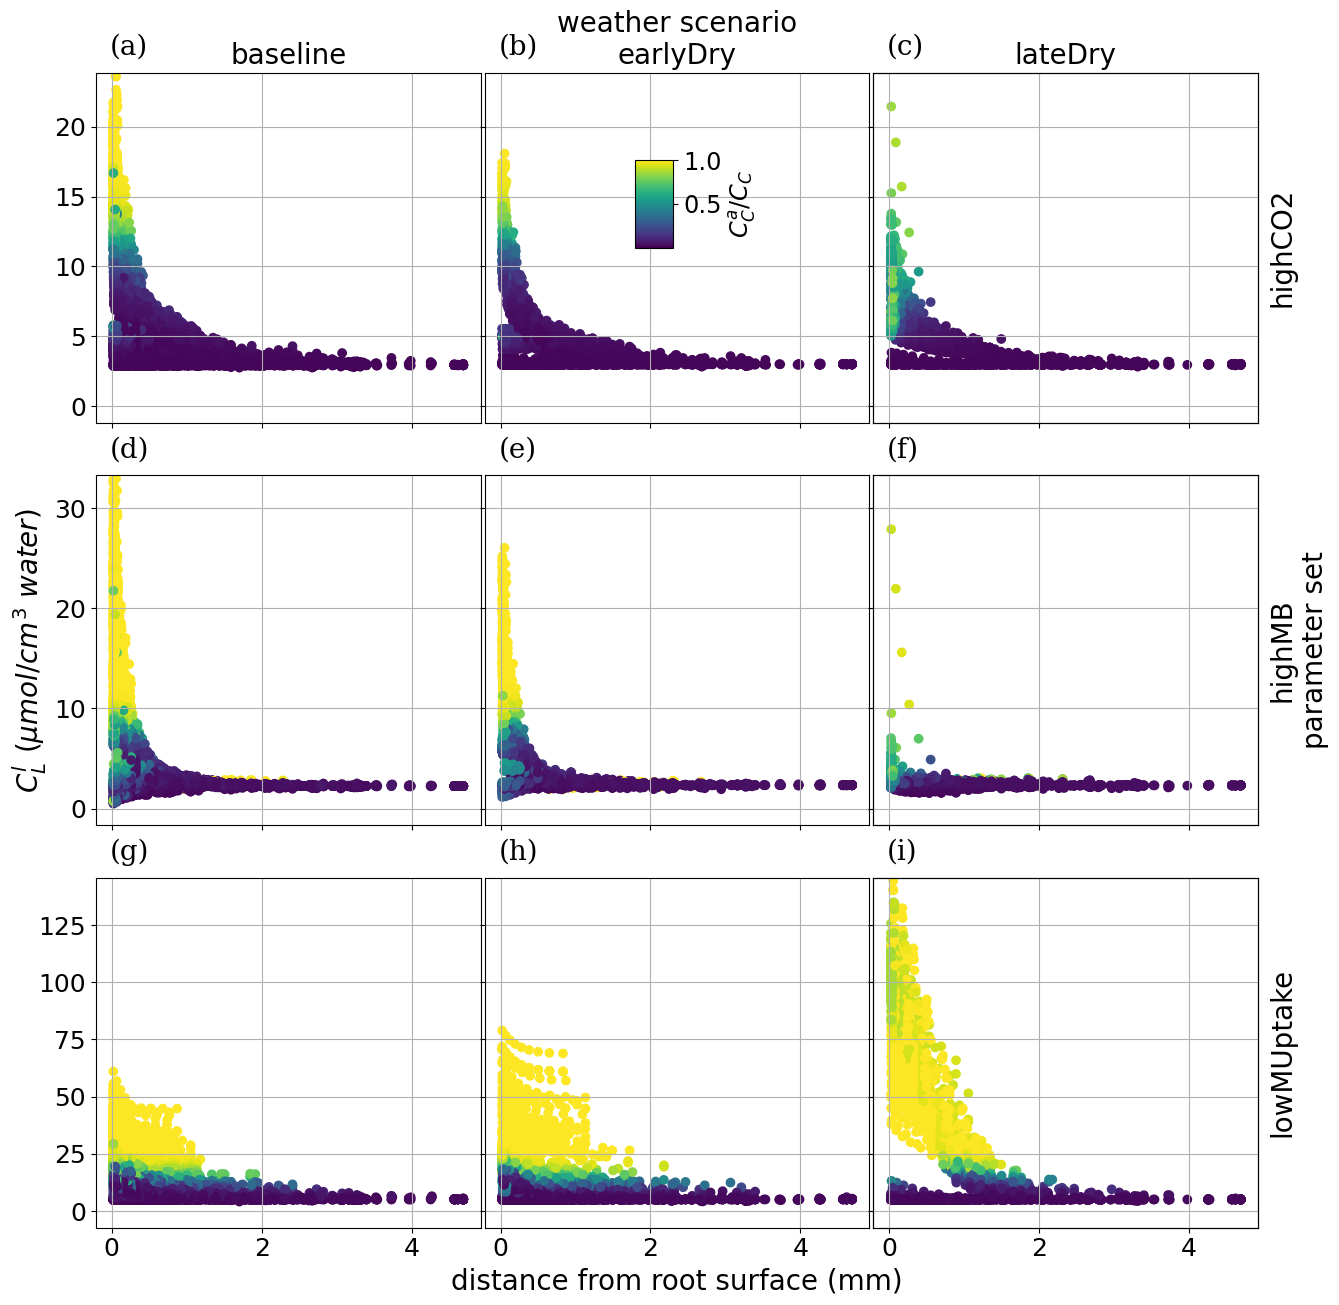

In [14]:
getValAlongR(dfcoord, dfcs,unitChangex=10,unitChangey=1e6,oneylimPerRow = True,
                       ylab="$C_L^l~(\mu mol/cm^3~water)$",
                       xlab="distance from root surface (mm)",loc_='upper right',
                   dosave=True, doshow=True, savedir='./radialkonz/',  
             collabel='$C_C^a/C_C$',colordf_=dfccat,
                       saveName='valCLl_colCCaCC',
                 #timeeval=alltime[-1],
          sizerows=15,sizecols=15,colidLegend=0, rowidLegend=1)

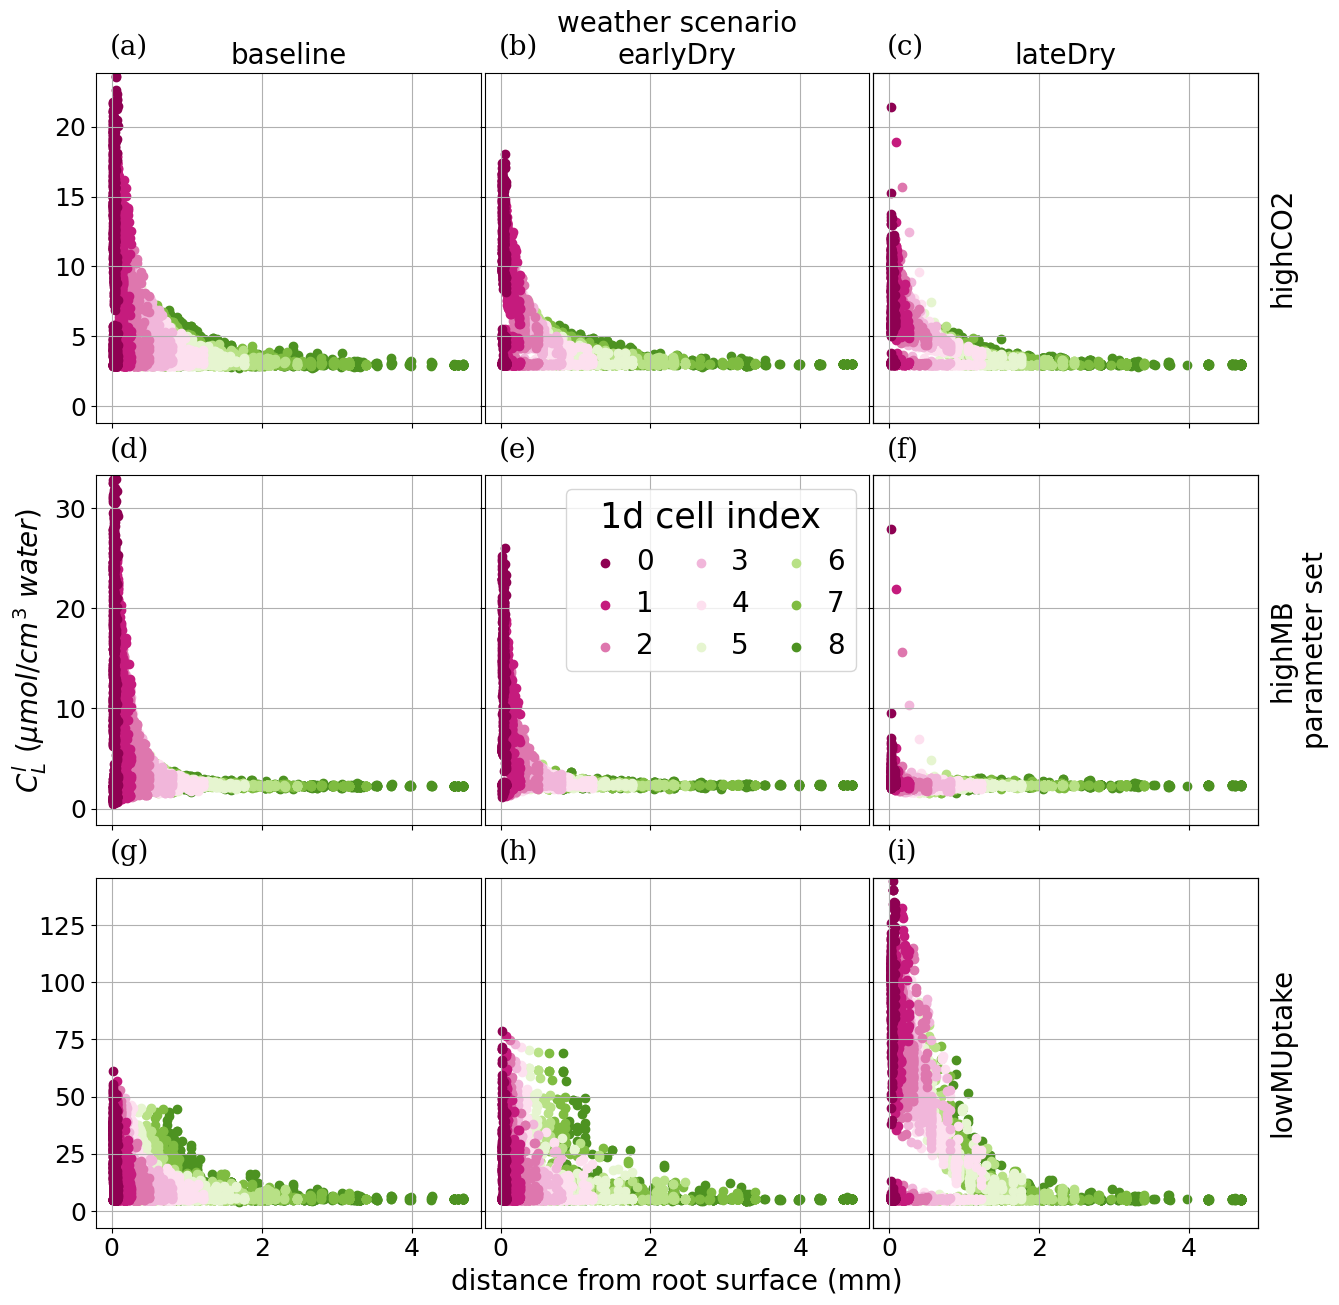

In [54]:
getValAlongR(dfcoord, dfcs,unitChangex=10,unitChangey=1e6,oneylimPerRow = True,
                       ylab="$C_L^l~(\mu mol/cm^3~water)$", 
                       xlab="distance from root surface (mm)",loc_='upper right',
                   dosave=True, doshow=True, savedir='./radialkonz/',  
                       saveName='CLl25_cellid',
          sizerows=15,sizecols=15,colidLegend=1, rowidLegend=1)